In [1]:
import os
import sys
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Environment ready!")

Environment ready!


In [2]:
!git clone -b ushara-eda https://github.com/Jana1805/DL-Assignment.git

Cloning into 'DL-Assignment'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 41 (delta 14), reused 33 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 12.64 MiB | 13.88 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [3]:
%cd /content/DL-Assignment

/content/DL-Assignment


In [4]:
!ls

ApacheJIT_Project_Brief.md  Initial_Steps.md  notebooks  requirements.txt
dataset			    links.txt	      readme.md


In [5]:
!find dataset -maxdepth 2 -type f

dataset/apachejit_test_small.csv
dataset/apachejit_total.csv
dataset/apachejit_test_large.csv
dataset/apachejit_train.csv
dataset/apachejit_total_with_messages.csv


In [6]:
import os

print(os.listdir("/content/DL-Assignment"))
print(os.listdir("/content/DL-Assignment/dataset"))

['Initial_Steps.md', '.gitignore', 'ApacheJIT_Project_Brief.md', 'dataset', 'readme.md', '.git', 'notebooks', 'requirements.txt', 'links.txt']
['apachejit_test_small.csv', 'apachejit_total.csv', 'apachejit_test_large.csv', 'apachejit_train.csv', 'apachejit_total_with_messages.csv']


In [7]:
import os

print("Repository files:")
print(os.listdir("/content/DL-Assignment"))

print("\nDataset files:")
print(os.listdir("/content/DL-Assignment/dataset"))

Repository files:
['Initial_Steps.md', '.gitignore', 'ApacheJIT_Project_Brief.md', 'dataset', 'readme.md', '.git', 'notebooks', 'requirements.txt', 'links.txt']

Dataset files:
['apachejit_test_small.csv', 'apachejit_total.csv', 'apachejit_test_large.csv', 'apachejit_train.csv', 'apachejit_total_with_messages.csv']


In [8]:
import pandas as pd

DATA_PATH = "/content/DL-Assignment/dataset/apachejit_total.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (106674, 18)


In [9]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os
import numpy as np

DATA_DIR = "/content/drive/MyDrive/DL-Assignment/data/processed_v2"

X_train_v2 = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train_v2 = np.load(os.path.join(DATA_DIR, "y_train.npy"))

X_val_v2 = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val_v2 = np.load(os.path.join(DATA_DIR, "y_val.npy"))

X_test_v2 = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test_v2 = np.load(os.path.join(DATA_DIR, "y_test.npy"))

class_weights_v2 = np.load(
    os.path.join(DATA_DIR, "class_weights.npy")
)

INPUT_DIM_V2 = X_train_v2.shape[1]

print("V2 data loaded successfully!")
print("X_train:", X_train_v2.shape)
print("X_val:", X_val_v2.shape)
print("X_test:", X_test_v2.shape)
print("Input dimension:", INPUT_DIM_V2)

V2 data loaded successfully!
X_train: (52133, 17)
X_val: (24430, 17)
X_test: (30111, 17)
Input dimension: 17


In [11]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106674 entries, 0 to 106673
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   commit_id    106674 non-null  object 
 1   project      106674 non-null  object 
 2   buggy        106674 non-null  bool   
 3   fix          106674 non-null  bool   
 4   year         106674 non-null  int64  
 5   author_date  106674 non-null  int64  
 6   la           106674 non-null  int64  
 7   ld           106674 non-null  int64  
 8   nf           106674 non-null  int64  
 9   nd           106674 non-null  int64  
 10  ns           106674 non-null  int64  
 11  ent          106674 non-null  float64
 12  ndev         106674 non-null  float64
 13  age          106674 non-null  float64
 14  nuc          106674 non-null  float64
 15  aexp         106674 non-null  int64  
 16  arexp        106674 non-null  float64
 17  asexp        106674 non-null  float64
dtypes: 

,commit_id,project,buggy,fix,year,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp
0,7b8480744ea6e6fb41efd4329bb470c8f3c763db,apache/groovy,False,False,2003,1070355653,372,23,8,3,3,2.669743,0.250000,3.625000,2.125,243,243.0,0.683585
1,192b631e7be302ecde822546ba70a9853ddbda01,apache/groovy,False,False,2003,1063298262,2,2,2,2,1,1.000000,1.000000,0.000000,2.500,19,19.0,14.000000
2,0ab6465a7dece117c61c3efd3ec95d20524bdad6,apache/groovy,False,False,2003,1069704572,41,26,3,3,2,1.237612,0.666667,5.333333,45.000,233,233.0,0.000606
3,449241d5fa1aeadd5eb9fa1280d4104dc0dfb891,apache/groovy,False,False,2003,1068487625,8,6,2,1,1,0.591673,1.000000,3.000000,35.500,64,64.0,55.000000
4,698df9f5b0816e05bbf97a390428f8ef94e0cdbf,apache/groovy,False,False,2003,1063313516,70,4,6,3,1,2.519672,0.333333,0.000000,6.000,27,27.0,22.000000


In [12]:
print("Buggy class distribution:")
print(df["buggy"].value_counts())

print("\nBuggy class proportions:")
print(df["buggy"].value_counts(normalize=True))

Buggy class distribution:
buggy
False    78435
True     28239
Name: count, dtype: int64

Buggy class proportions:
buggy
False    0.735278
True     0.264722
Name: proportion, dtype: float64


In [13]:
print("Minimum year:", df["year"].min())
print("Maximum year:", df["year"].max())

print("\nCommits by year:")
print(df["year"].value_counts().sort_index())

Minimum year: 2003
Maximum year: 2019

Commits by year:
year
2003      295
2004      517
2005      717
2006     1417
2007     2331
2008     3218
2009     5305
2010     4973
2011     7117
2012     6923
2013     7001
2014    12319
2015    13824
2016    10606
2017    10187
2018     9365
2019    10559
Name: count, dtype: int64


In [14]:
train_df = df[df["year"] <= 2014].copy()

val_df = df[
    (df["year"] >= 2015) &
    (df["year"] <= 2016)
].copy()

test_df = df[df["year"] >= 2017].copy()

print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

print("\nYear ranges:")
print("Training:", train_df["year"].min(), "-", train_df["year"].max())
print("Validation:", val_df["year"].min(), "-", val_df["year"].max())
print("Test:", test_df["year"].min(), "-", test_df["year"].max())

Training set: (52133, 18)
Validation set: (24430, 18)
Test set: (30111, 18)

Year ranges:
Training: 2003 - 2014
Validation: 2015 - 2016
Test: 2017 - 2019


In [15]:
FEATURE_COLUMNS = [
    "la", "ld", "nf", "nd", "ns", "ent",
    "ndev", "age", "nuc", "aexp", "arexp", "asexp"
]

TARGET_COLUMN = "buggy"

X_train = train_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET_COLUMN].astype(int).copy()

X_val = val_df[FEATURE_COLUMNS].copy()
y_val = val_df[TARGET_COLUMN].astype(int).copy()

X_test = test_df[FEATURE_COLUMNS].copy()
y_test = test_df[TARGET_COLUMN].astype(int).copy()

print("Number of features:", len(FEATURE_COLUMNS))

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFeatures:")
print(FEATURE_COLUMNS)

Number of features: 12

X_train: (52133, 12)
y_train: (52133,)
X_val: (24430, 12)
y_val: (24430,)
X_test: (30111, 12)
y_test: (30111,)

Features:
['la', 'ld', 'nf', 'nd', 'ns', 'ent', 'ndev', 'age', 'nuc', 'aexp', 'arexp', 'asexp']


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

print("\nShapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

print("\nTraining mean:")
print(np.round(X_train_scaled.mean(axis=0), 3))

print("\nTraining standard deviation:")
print(np.round(X_train_scaled.std(axis=0), 3))

Scaling completed!

Shapes:
X_train_scaled: (52133, 12)
X_val_scaled: (24430, 12)
X_test_scaled: (30111, 12)

Training mean:
[ 0.  0. -0.  0.  0. -0. -0.  0. -0.  0. -0. -0.]

Training standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [17]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

print("Class weights:")
print("Clean (0):", class_weights[0])
print("Buggy (1):", class_weights[1])

print("\nTraining class counts:")
print(y_train.value_counts())

Class weights:
Clean (0): 0.7051288987475316
Buggy (1): 1.7187458789397336

Training class counts:
buggy
0    36967
1    15166
Name: count, dtype: int64


In [18]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("PyTorch DataLoaders created successfully!")

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

PyTorch DataLoaders created successfully!
Training batches: 204
Validation batches: 96
Test batches: 118


In [19]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert V2 data to PyTorch tensors
X_train_tensor_v2 = torch.tensor(X_train_v2, dtype=torch.float32)
y_train_tensor_v2 = torch.tensor(y_train_v2, dtype=torch.long)

X_val_tensor_v2 = torch.tensor(X_val_v2, dtype=torch.float32)
y_val_tensor_v2 = torch.tensor(y_val_v2, dtype=torch.long)

X_test_tensor_v2 = torch.tensor(X_test_v2, dtype=torch.float32)
y_test_tensor_v2 = torch.tensor(y_test_v2, dtype=torch.long)

# Create datasets
train_dataset_v2 = TensorDataset(
    X_train_tensor_v2,
    y_train_tensor_v2
)

val_dataset_v2 = TensorDataset(
    X_val_tensor_v2,
    y_val_tensor_v2
)

test_dataset_v2 = TensorDataset(
    X_test_tensor_v2,
    y_test_tensor_v2
)

# DataLoaders
BATCH_SIZE = 256

train_loader_v2 = DataLoader(
    train_dataset_v2,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_v2 = DataLoader(
    val_dataset_v2,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_v2 = DataLoader(
    test_dataset_v2,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("V2 PyTorch DataLoaders created successfully!")
print("Training batches:", len(train_loader_v2))
print("Validation batches:", len(val_loader_v2))
print("Test batches:", len(test_loader_v2))

V2 PyTorch DataLoaders created successfully!
Training batches: 204
Validation batches: 96
Test batches: 118


In [20]:
import torch
import torch.nn as nn


class WideAndDeep(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Wide part
        self.wide = nn.Linear(input_dim, 2)

        # Deep part
        self.deep = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        wide_output = self.wide(x)
        deep_output = self.deep(x)

        # Combine wide + deep predictions
        output = wide_output + deep_output

        return output


INPUT_DIM = X_train_scaled.shape[1]

model = WideAndDeep(INPUT_DIM)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("\nInput features:", INPUT_DIM)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

WideAndDeep(
  (wide): Linear(in_features=12, out_features=2, bias=True)
  (deep): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=2, bias=True)
  )
)

Input features: 12
Total parameters: 12476
Trainable parameters: 12476


In [29]:
import torch
import torch.nn as nn


class WideAndDeepV2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Wide part
        self.wide = nn.Linear(input_dim, 2)

        # Deep part
        self.deep = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        wide_output = self.wide(x)
        deep_output = self.deep(x)

        # Combine wide + deep predictions
        return wide_output + deep_output


# V2 has 17 features
INPUT_DIM_V2 = X_train_v2.shape[1]

model_v2 = WideAndDeepV2(INPUT_DIM_V2)

print(model_v2)

total_params_v2 = sum(
    p.numel() for p in model_v2.parameters()
)

trainable_params_v2 = sum(
    p.numel()
    for p in model_v2.parameters()
    if p.requires_grad
)

print("\nV2 Input features:", INPUT_DIM_V2)
print("Total parameters:", total_params_v2)
print("Trainable parameters:", trainable_params_v2)

WideAndDeepV2(
  (wide): Linear(in_features=17, out_features=2, bias=True)
  (deep): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=2, bias=True)
  )
)

V2 Input features: 17
Total parameters: 13126
Trainable parameters: 13126


In [21]:
import torch.optim as optim

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = model.to(device)

# Convert class weights to a PyTorch tensor
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

# Weighted Cross-Entropy Loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Learning-rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print("Device:", device)
print("Loss function: Weighted CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Device: cpu
Loss function: Weighted CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [30]:
import torch.optim as optim

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move V2 model to device
model_v2 = model_v2.to(device)

# Convert V2 class weights to tensor
class_weights_tensor_v2 = torch.tensor(
    class_weights_v2,
    dtype=torch.float32
).to(device)

# Weighted Cross-Entropy Loss
criterion_v2 = nn.CrossEntropyLoss(
    weight=class_weights_tensor_v2
)

# Adam optimizer
optimizer_v2 = optim.Adam(
    model_v2.parameters(),
    lr=1e-3
)

# Learning-rate scheduler
scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2,
    mode="min",
    factor=0.5,
    patience=5
)

print("V2 setup completed!")
print("Device:", device)
print("Loss function: Weighted CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

V2 setup completed!
Device: cpu
Loss function: Weighted CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy


def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy


print("Training and validation functions created successfully!")

Training and validation functions created successfully!


In [35]:
import time

NUM_EPOCHS = 50
PATIENCE = 7

best_val_loss_v2 = float("inf")
patience_counter_v2 = 0

train_losses_v2 = []
val_losses_v2 = []
train_accuracies_v2 = []
val_accuracies_v2 = []

best_model_state_v2 = None

# Start timer
start_time_v2 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model_v2,
        train_loader_v2,
        criterion_v2,
        optimizer_v2,
        device
    )

    val_loss, val_acc = validate(
        model_v2,
        val_loader_v2,
        criterion_v2,
        device
    )

    scheduler_v2.step(val_loss)

    train_losses_v2.append(train_loss)
    val_losses_v2.append(val_loss)
    train_accuracies_v2.append(train_acc)
    val_accuracies_v2.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss_v2:
        best_val_loss_v2 = val_loss
        patience_counter_v2 = 0

        best_model_state_v2 = {
            key: value.cpu().clone()
            for key, value in model_v2.state_dict().items()
        }

    else:
        patience_counter_v2 += 1

    # Early stopping
    if patience_counter_v2 >= PATIENCE:
        print("\nEarly stopping triggered.")
        break

# Stop timer
end_time_v2 = time.time()

# Calculate training time
training_time_v2 = end_time_v2 - start_time_v2

# Restore best V2 model
model_v2.load_state_dict(best_model_state_v2)

print("\nBest V2 validation loss:", best_val_loss_v2)
print("V2 training completed!")

print(f"\nV2 Training Time: {training_time_v2:.2f} seconds")
print(f"V2 Training Time: {training_time_v2 / 60:.2f} minutes")
print(f"V2 Epochs Completed: {epoch}")

Epoch 01/50 | Train Loss: 0.5403 | Train Acc: 0.7298 | Val Loss: 0.5404 | Val Acc: 0.7262
Epoch 02/50 | Train Loss: 0.5389 | Train Acc: 0.7289 | Val Loss: 0.5422 | Val Acc: 0.7261
Epoch 03/50 | Train Loss: 0.5384 | Train Acc: 0.7320 | Val Loss: 0.5418 | Val Acc: 0.7295
Epoch 04/50 | Train Loss: 0.5385 | Train Acc: 0.7308 | Val Loss: 0.5414 | Val Acc: 0.7342
Epoch 05/50 | Train Loss: 0.5372 | Train Acc: 0.7308 | Val Loss: 0.5438 | Val Acc: 0.7275
Epoch 06/50 | Train Loss: 0.5367 | Train Acc: 0.7317 | Val Loss: 0.5421 | Val Acc: 0.7293
Epoch 07/50 | Train Loss: 0.5343 | Train Acc: 0.7345 | Val Loss: 0.5452 | Val Acc: 0.7264
Epoch 08/50 | Train Loss: 0.5338 | Train Acc: 0.7344 | Val Loss: 0.5448 | Val Acc: 0.7217

Early stopping triggered.

Best V2 validation loss: 0.5404153184816577
V2 training completed!

V2 Training Time: 12.87 seconds
V2 Training Time: 0.21 minutes
V2 Epochs Completed: 8


In [34]:
import time

NUM_EPOCHS = 50
PATIENCE = 7

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_model_state = None

# Start timer
start_time_v1 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= PATIENCE:
        print("\nEarly stopping triggered.")
        break

# Stop timer
end_time_v1 = time.time()

# Calculate training time
training_time_v1 = end_time_v1 - start_time_v1

# Restore best V1 model
model.load_state_dict(best_model_state)

print("\nBest V1 validation loss:", best_val_loss)
print("V1 training completed!")

print(f"\nV1 Training Time: {training_time_v1:.2f} seconds")
print(f"V1 Training Time: {training_time_v1 / 60:.2f} minutes")
print(f"V1 Epochs Completed: {epoch}")

Epoch 01/50 | Train Loss: 0.5537 | Train Acc: 0.7263 | Val Loss: 0.5527 | Val Acc: 0.7395
Epoch 02/50 | Train Loss: 0.5523 | Train Acc: 0.7249 | Val Loss: 0.5554 | Val Acc: 0.7423
Epoch 03/50 | Train Loss: 0.5500 | Train Acc: 0.7278 | Val Loss: 0.5500 | Val Acc: 0.7385
Epoch 04/50 | Train Loss: 0.5509 | Train Acc: 0.7274 | Val Loss: 0.5540 | Val Acc: 0.7384
Epoch 05/50 | Train Loss: 0.5496 | Train Acc: 0.7287 | Val Loss: 0.5515 | Val Acc: 0.7401
Epoch 06/50 | Train Loss: 0.5488 | Train Acc: 0.7281 | Val Loss: 0.5491 | Val Acc: 0.7354
Epoch 07/50 | Train Loss: 0.5476 | Train Acc: 0.7278 | Val Loss: 0.5507 | Val Acc: 0.7393
Epoch 08/50 | Train Loss: 0.5472 | Train Acc: 0.7285 | Val Loss: 0.5544 | Val Acc: 0.7413
Epoch 09/50 | Train Loss: 0.5468 | Train Acc: 0.7271 | Val Loss: 0.5521 | Val Acc: 0.7370
Epoch 10/50 | Train Loss: 0.5467 | Train Acc: 0.7310 | Val Loss: 0.5535 | Val Acc: 0.7332
Epoch 11/50 | Train Loss: 0.5461 | Train Acc: 0.7285 | Val Loss: 0.5505 | Val Acc: 0.7363
Epoch 12/5

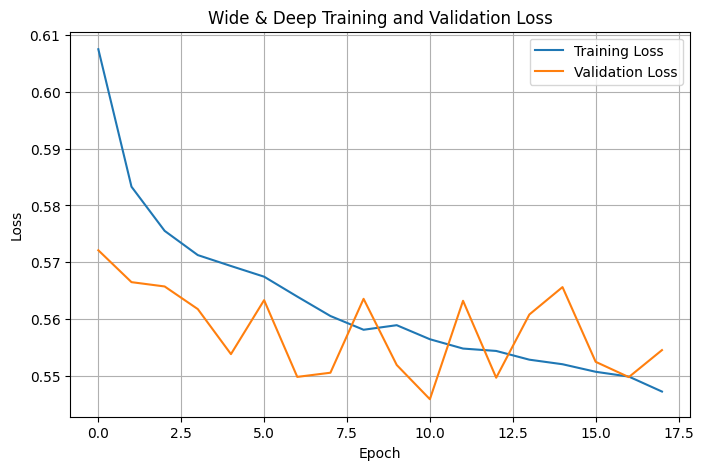

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Wide & Deep Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(y_batch.numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())


# Calculate metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
roc_auc = roc_auc_score(all_labels, all_probabilities)

print("===== Wide & Deep Test Results =====")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Clean", "Buggy"]
    )
)

===== Wide & Deep Test Results =====
Accuracy : 0.6930
Precision: 0.3568
Recall   : 0.7332
F1 Score : 0.4800
ROC-AUC  : 0.7745

Classification Report:
              precision    recall  f1-score   support

       Clean       0.91      0.68      0.78     24293
       Buggy       0.36      0.73      0.48      5818

    accuracy                           0.69     30111
   macro avg       0.64      0.71      0.63     30111
weighted avg       0.81      0.69      0.72     30111



In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

model_v2.eval()

all_labels_v2 = []
all_predictions_v2 = []
all_probabilities_v2 = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_v2:

        X_batch = X_batch.to(device)

        outputs = model_v2(X_batch)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = torch.argmax(outputs, dim=1)

        all_labels_v2.extend(y_batch.numpy())
        all_predictions_v2.extend(predictions.cpu().numpy())
        all_probabilities_v2.extend(probabilities.cpu().numpy())


# Calculate metrics
accuracy_v2 = accuracy_score(
    all_labels_v2,
    all_predictions_v2
)

precision_v2 = precision_score(
    all_labels_v2,
    all_predictions_v2,
    zero_division=0
)

recall_v2 = recall_score(
    all_labels_v2,
    all_predictions_v2,
    zero_division=0
)

f1_v2 = f1_score(
    all_labels_v2,
    all_predictions_v2,
    zero_division=0
)

roc_auc_v2 = roc_auc_score(
    all_labels_v2,
    all_probabilities_v2
)

pr_auc_v2 = average_precision_score(
    all_labels_v2,
    all_probabilities_v2
)

print("===== Wide & Deep V2 Test Results =====")

print(f"Accuracy : {accuracy_v2:.4f}")
print(f"Precision: {precision_v2:.4f}")
print(f"Recall   : {recall_v2:.4f}")
print(f"F1 Score : {f1_v2:.4f}")
print(f"ROC-AUC  : {roc_auc_v2:.4f}")
print(f"PR-AUC   : {pr_auc_v2:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels_v2,
        all_predictions_v2,
        target_names=["Clean", "Buggy"],
        zero_division=0
    )
)

===== Wide & Deep V2 Test Results =====
Accuracy : 0.6616
Precision: 0.3356
Recall   : 0.7674
F1 Score : 0.4670
ROC-AUC  : 0.7776
PR-AUC   : 0.4597

Classification Report:
              precision    recall  f1-score   support

       Clean       0.92      0.64      0.75     24293
       Buggy       0.34      0.77      0.47      5818

    accuracy                           0.66     30111
   macro avg       0.63      0.70      0.61     30111
weighted avg       0.81      0.66      0.70     30111



In [26]:
from sklearn.metrics import average_precision_score

pr_auc_v1 = average_precision_score(
    all_labels,
    all_probabilities
)

print("Wide & Deep V1 PR-AUC:", round(pr_auc_v1, 4))

Wide & Deep V1 PR-AUC: 0.4599


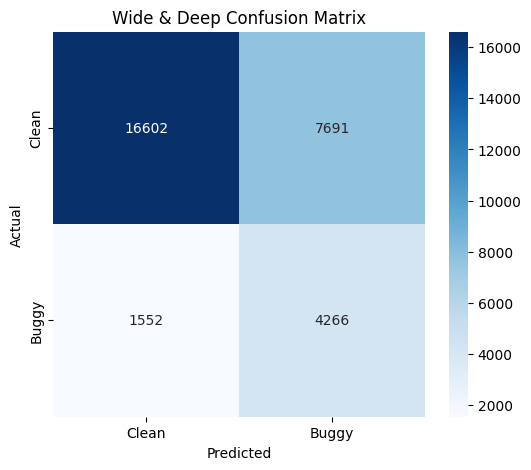

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Clean", "Buggy"],
    yticklabels=["Clean", "Buggy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Wide & Deep Confusion Matrix")

plt.show()

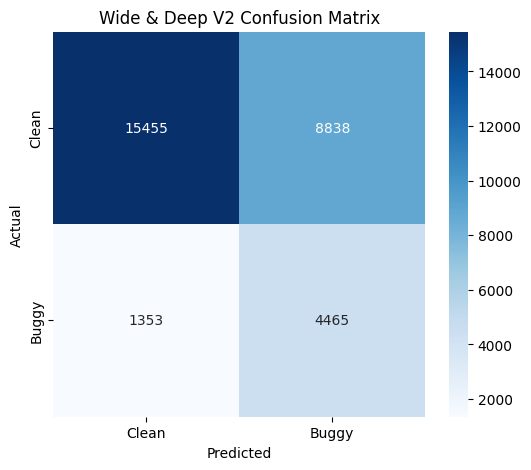

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_v2 = confusion_matrix(
    all_labels_v2,
    all_predictions_v2
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Clean", "Buggy"],
    yticklabels=["Clean", "Buggy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Wide & Deep V2 Confusion Matrix")

plt.show()

In [28]:
!cp /content/03_Wide_Deep.ipynb /content/DL-Assignment/

cp: cannot stat '/content/03_Wide_Deep.ipynb': No such file or directory
